<a href="https://colab.research.google.com/github/Aakanksha-6/playstore/blob/google-play-store-apps/1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Google Play Store Data Analysis (Final Notebook)
Complete workflow based on PDF + advanced improvements

## 1. Import Libraries

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [135]:
df = pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [136]:
df2= pd.read_csv('googleplaystore_user_reviews.csv')

df2

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000
...,...,...,...,...,...
64290,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64291,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64292,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN
64293,Houzz Interior Design Ideas,NaN,NaN,NaN,NaN


## 3. Data Exploration

In [137]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [138]:
df.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [139]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [140]:
df.tail()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device
10840,iHoroscope - 2018 Daily Horoscope & Astrology,LIFESTYLE,4.5,398307,19M,"10,000,000+",Free,0,Everyone,Lifestyle,"July 25, 2018",Varies with device,Varies with device


In [141]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [142]:
df2.describe()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.000000,37432.000000
mean,0.182146,0.492704
std,0.351301,0.259949
min,-1.000000,0.000000
25%,0.000000,0.357143
50%,0.150000,0.514286
75%,0.400000,0.650000
max,1.000000,1.000000


## 4. Data Cleaning

In [143]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert columns
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')
df['Price'] = df['Price'].str.replace('$', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Handle missing values (better method)
df['Rating'] = df.groupby('Installs')['Rating'].transform(lambda x: x.fillna(x.mean()))

In [144]:
df['Size'].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [145]:
def fix_size(s):
  try:
    if s.endswith('M'):
      return float(s[:-1])
    elif s.endswith('k'):
      return (float(s[:-1]) / 1024)
    elif s == '1,000+':
      return 1.0
    else:
      return np.nan
  except:
      return np.nan

In [146]:
fix_size('98M')

98.0

In [147]:
fix_size('45k')

0.0439453125

In [148]:
df['Size']= df['Size'].apply(fix_size)

In [149]:
df['Size'].unique()

array([1.90000000e+01, 1.40000000e+01, 8.70000000e+00, 2.50000000e+01,
       2.80000000e+00, 5.60000000e+00, 2.90000000e+01, 3.30000000e+01,
       3.10000000e+00, 2.80000000e+01, 1.20000000e+01, 2.00000000e+01,
       2.10000000e+01, 3.70000000e+01, 2.70000000e+00, 5.50000000e+00,
       1.70000000e+01, 3.90000000e+01, 3.10000000e+01, 4.20000000e+00,
       7.00000000e+00, 2.30000000e+01, 6.00000000e+00, 6.10000000e+00,
       4.60000000e+00, 9.20000000e+00, 5.20000000e+00, 1.10000000e+01,
       2.40000000e+01,            nan, 9.40000000e+00, 1.50000000e+01,
       1.00000000e+01, 1.20000000e+00, 2.60000000e+01, 8.00000000e+00,
       7.90000000e+00, 5.60000000e+01, 5.70000000e+01, 3.50000000e+01,
       5.40000000e+01, 1.96289062e-01, 3.60000000e+00, 5.70000000e+00,
       8.60000000e+00, 2.40000000e+00, 2.70000000e+01, 2.50000000e+00,
       1.60000000e+01, 3.40000000e+00, 8.90000000e+00, 3.90000000e+00,
       2.90000000e+00, 3.80000000e+01, 3.20000000e+01, 5.40000000e+00,
      

In [150]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10358 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10358 non-null  object 
 1   Category        10358 non-null  object 
 2   Rating          10342 non-null  float64
 3   Reviews         10357 non-null  float64
 4   Size            8832 non-null   float64
 5   Installs        10357 non-null  float64
 6   Type            10357 non-null  object 
 7   Price           9592 non-null   float64
 8   Content Rating  10357 non-null  object 
 9   Genres          10358 non-null  object 
 10  Last Updated    10358 non-null  object 
 11  Current Ver     10350 non-null  object 
 12  Android Ver     10355 non-null  object 
dtypes: float64(5), object(8)
memory usage: 1.1+ MB


## 5. Feature Engineering

In [151]:
def install_group(x):
    if x < 10000:
        return 'Low'
    elif x < 1000000:
        return 'Moderate'
    elif x < 10000000:
        return 'High'
    else:
        return 'Top Notch'

df['Installs_category'] = df['Installs'].apply(install_group)

# Convert date
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')

## 6. Exploratory Data Analysis

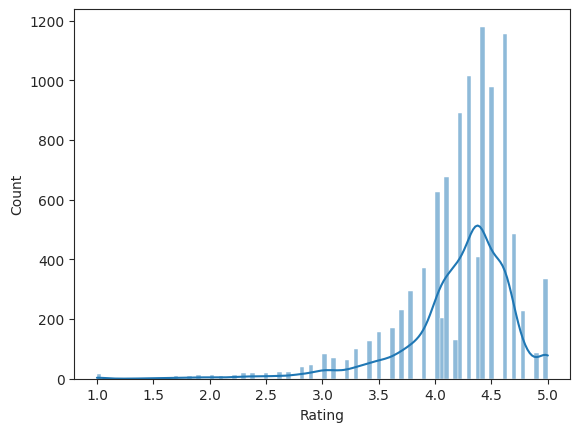

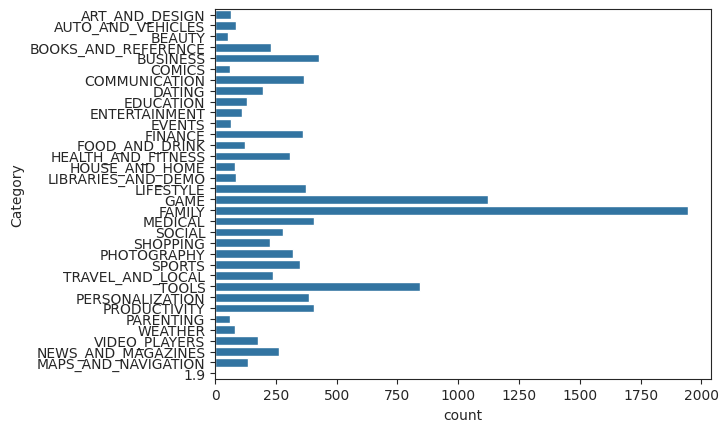

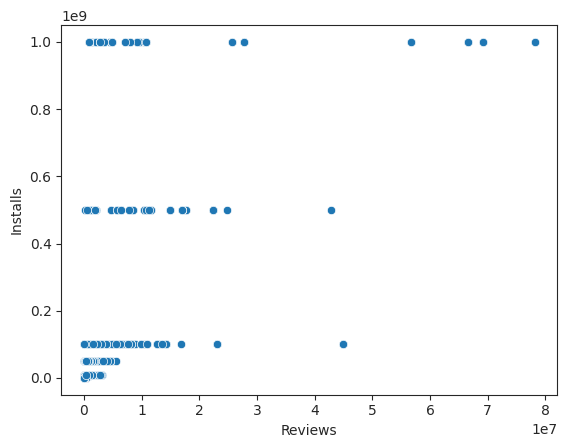

In [152]:
# Rating distribution
sns.histplot(df['Rating'], kde=True)
plt.show()

# Category count
sns.countplot(y='Category', data=df)
plt.show()

# Reviews vs Installs
sns.scatterplot(x='Reviews', y='Installs', data=df)
plt.show()

## 7. Advanced Analysis

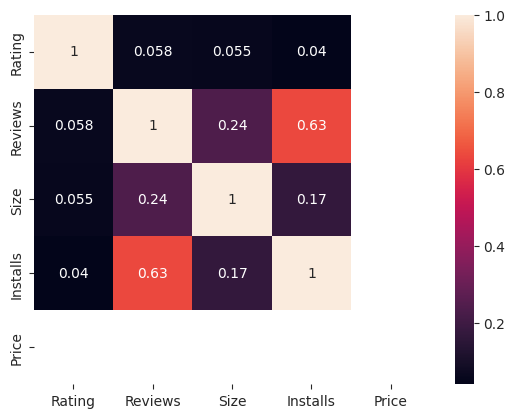

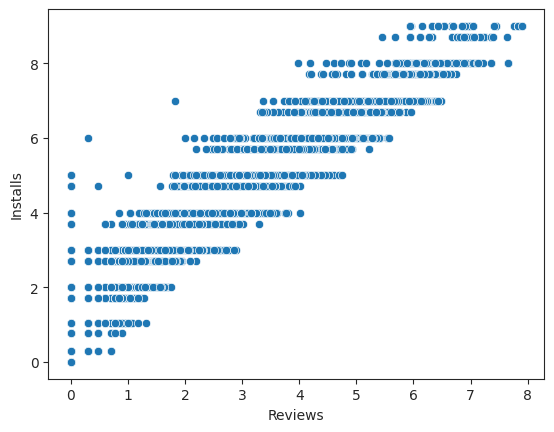

In [153]:
# Correlation heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

# Log transformation plot
sns.scatterplot(x=np.log10(df['Reviews']+1), y=np.log10(df['Installs']+1))
plt.show()

## 8. Category Insights

In [154]:
df.groupby('Category')[['Rating','Installs','Reviews']].mean()

,Rating,Installs,Reviews
Category,,,
1.9,NaN,NaN,NaN
ART_AND_DESIGN,4.348950,1.912894e+06,2.637600e+04
AUTO_AND_VEHICLES,4.244190,6.250613e+05,1.369019e+04
BEAUTY,4.259867,5.131519e+05,7.476226e+03
BOOKS_AND_REFERENCE,4.360517,8.332476e+06,9.510099e+04
BUSINESS,4.224734,2.022634e+06,2.894185e+04
COMICS,4.157831,9.347692e+05,5.638793e+04
COMMUNICATION,4.187134,6.598983e+07,1.642824e+06
DATING,4.053008,1.053756e+06,2.829284e+04


## 9. Top Apps

In [155]:
df.sort_values(by='Installs', ascending=False)[['App','Installs']].head(10)

,App,Installs
3454,Google Drive,1.000000e+09
865,Google Play Games,1.000000e+09
3523,Google Drive,1.000000e+09
2544,Facebook,1.000000e+09
2545,Instagram,1.000000e+09
464,Hangouts,1.000000e+09
3223,Maps - Navigate & Explore,1.000000e+09
3816,Google News,1.000000e+09
4170,Google Drive,1.000000e+09
3896,Subway Surfers,1.000000e+09


In [156]:
def install_group(x):
    if x < 10000:
        return "Low"
    elif x < 1000000:
        return "Moderate"
    elif x < 10000000:
        return "High"
    else:
        return "Top Notch"

df['Installs_category'] = df['Installs'].apply(install_group)

In [157]:
df['Category'].value_counts()

,count
Category,
FAMILY,1943
GAME,1121
TOOLS,843
BUSINESS,427
MEDICAL,408
PRODUCTIVITY,407
PERSONALIZATION,388
LIFESTYLE,373
COMMUNICATION,366


In [158]:
df.groupby('Category')['Installs'].sum()

,Installs
Category,
1.9,0.000000e+00
ART_AND_DESIGN,1.243381e+08
AUTO_AND_VEHICLES,5.313021e+07
BEAUTY,2.719705e+07
BOOKS_AND_REFERENCE,1.916470e+09
BUSINESS,8.636649e+08
COMICS,5.608615e+07
COMMUNICATION,2.415228e+10
DATING,2.065361e+08


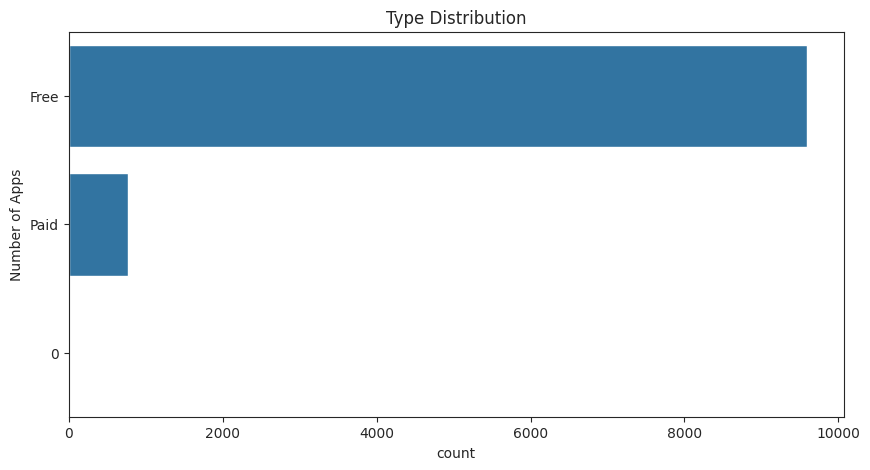

In [159]:
plt.figure(figsize=(10, 5))
sns.countplot(df['Type'])
plt.title('Type Distribution')
plt.ylabel('Number of Apps')
plt.show()

In [161]:
merged_df = pd.merge(df, df2, on = "App")


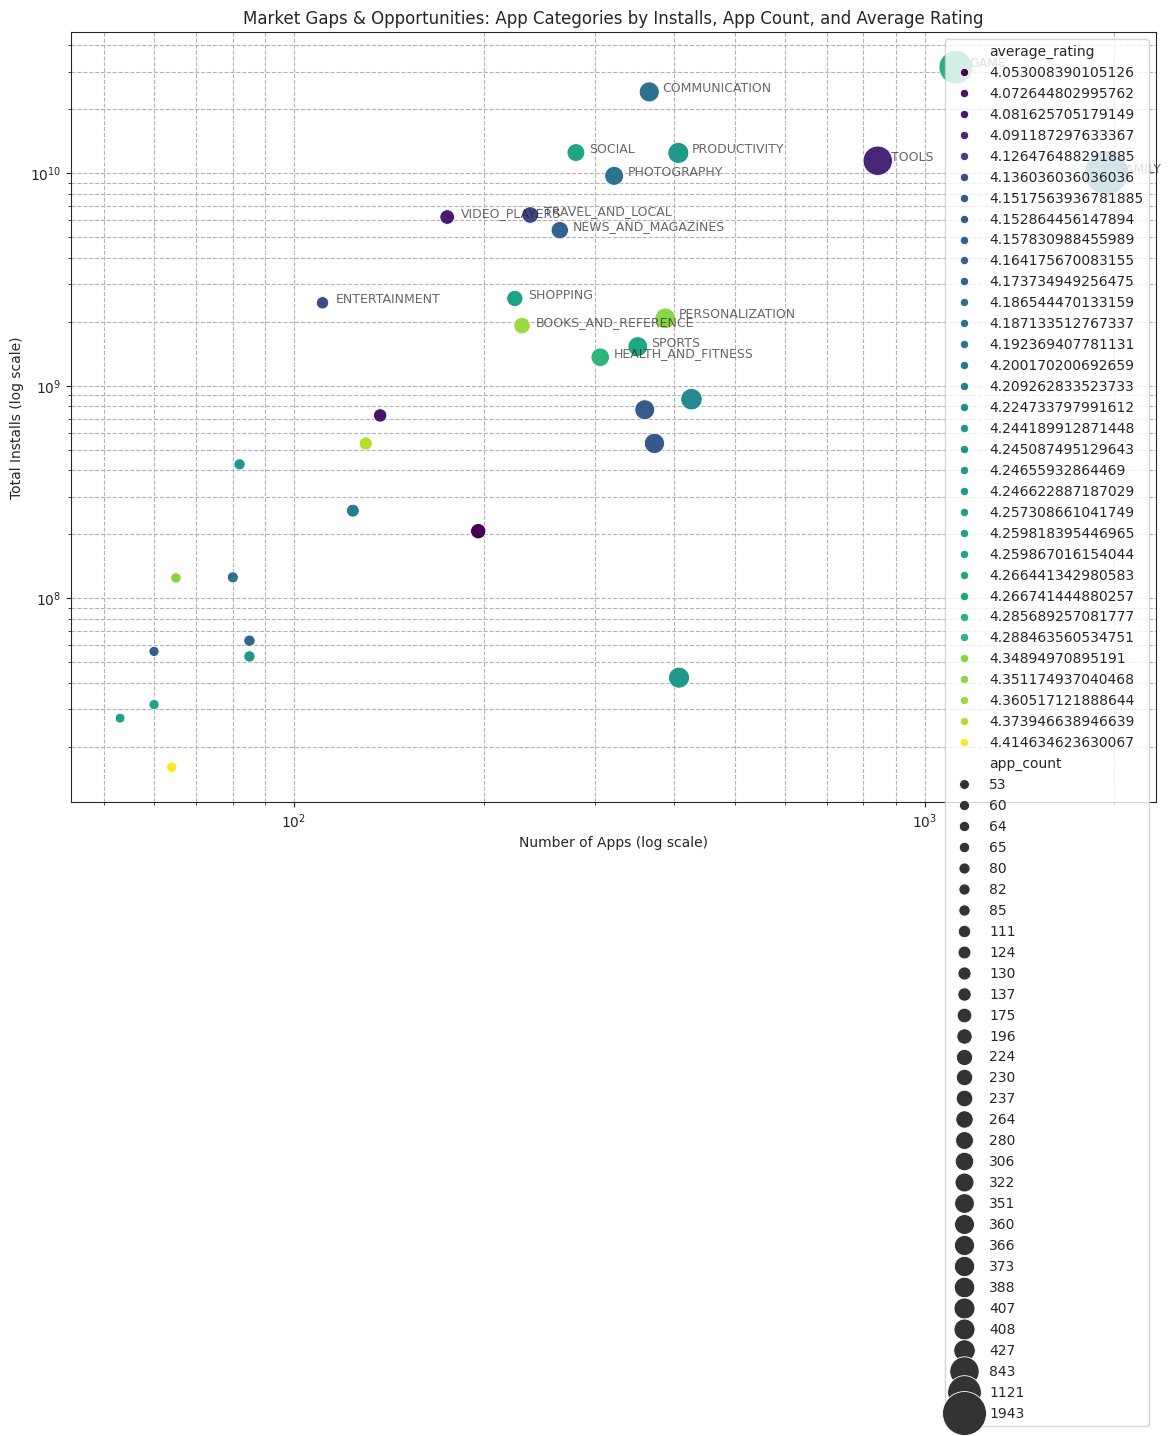

In [174]:
# Calculate total installs and app count per category
category_summary = df.groupby('Category').agg(
    total_installs=('Installs', 'sum'),
    app_count=('App', 'count'),
    average_rating=('Rating', 'mean')
).reset_index()

# Filter out the '1.9' category if it exists and is an anomaly
category_summary = category_summary[category_summary['Category'] != '1.9']

plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=category_summary,
    x='app_count',
    y='total_installs',
    hue='average_rating',
    size='app_count', # Size points by app count to emphasize larger categories
    sizes=(50, 1000),
    palette='viridis', # Use a diverging color palette for ratings
    legend='full'
)

plt.xscale('log')
plt.yscale('log')
plt.title('Market Gaps & Opportunities: App Categories by Installs, App Count, and Average Rating')
plt.xlabel('Number of Apps (log scale)')
plt.ylabel('Total Installs (log scale)')
plt.grid(True, which="both", ls="--", c='0.7')

# Add annotations for a few interesting categories
for i, row in category_summary.iterrows():
    if row['app_count'] > 500 or row['total_installs'] > 1e9:
        plt.text(row['app_count'] * 1.05, row['total_installs'], row['Category'], fontsize=9, alpha=0.7)

plt.show()

Text(0.5, 1.0, 'Sentiment Polarity Distribution')

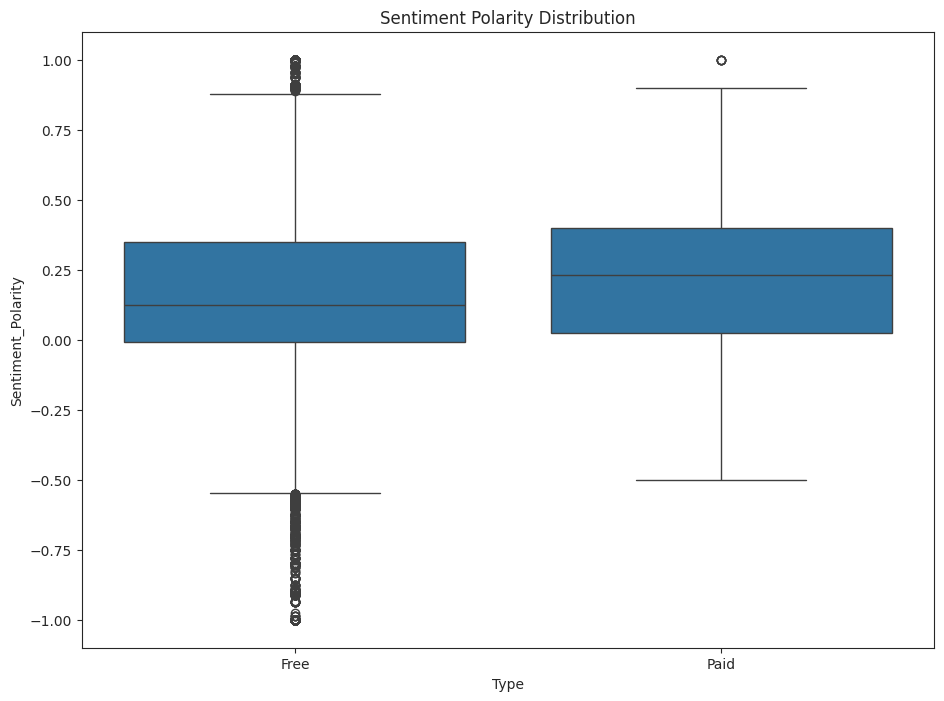

In [162]:
sns.set_style('ticks')
fig, ax = plt.subplots()
fig.set_size_inches(11, 8)


ax = sns.boxplot(x = 'Type', y = 'Sentiment_Polarity', data = merged_df)
ax.set_title('Sentiment Polarity Distribution')


## 10. Machine Learning Model

In [164]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Combine the features and target into a single DataFrame for NaN handling
df_model = df[['Reviews','Installs','Price', 'Rating']].dropna()

X = df_model[['Reviews','Installs','Price']]
y = df_model['Rating']

model = LinearRegression()
model.fit(X, y)

pred = model.predict(X)
print('R2 Score:', r2_score(y, pred))

R2 Score: 0.004055676674145636


In [170]:
df['Size'] = df['Size'].fillna(df['Size'].median())

# Calculate days since last update
latest_update = df['Last Updated'].max()
df['days_since_last_update'] = (latest_update - df['Last Updated']).dt.days

# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=['Category', 'Type', 'Content Rating'], drop_first=True)

In [171]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Prepare the features including the new encoded columns and 'Size' and 'days_since_last_update'
features = ['Reviews', 'Installs', 'Price', 'Size', 'days_since_last_update'] + list(df_encoded.filter(like='Category_').columns) + \
           list(df_encoded.filter(like='Type_').columns) + list(df_encoded.filter(like='Content Rating_').columns)

# Combine features and target into a single DataFrame for NaN handling
df_model_new = df_encoded[features + ['Rating']].dropna()

X_new = df_model_new[features]
y_new = df_model_new['Rating']

model_new = LinearRegression()
model_new.fit(X_new, y_new)

pred_new = model_new.predict(X_new)
print('R2 Score with new features:', r2_score(y_new, pred_new))

R2 Score with new features: 0.04701260060053003


In [172]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# Assuming X_new and y_new are already prepared from the previous step
# If not, ensure df_encoded and feature engineering steps are run

# Drop any remaining NaN values from X_new or y_new that might have appeared due to merging/encoding issues
# This ensures the model receives clean data.
# Re-create df_model_new to ensure consistency after previous operations.
# (Re-running this in case previous cell was run partially or for clarity)
df_model_new = df_encoded[features + ['Rating']].dropna()
X_final = df_model_new[features]
y_final = df_model_new['Rating']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f'Random Forest R2 Score: {r2_rf}')
print(f'Random Forest Mean Absolute Error: {mae_rf}')

# Feature Importances (Business Insight)
feature_importances = pd.Series(rf_model.feature_importances_, index=X_final.columns).sort_values(ascending=False)
print('\nTop 10 Feature Importances:')
print(feature_importances.head(10))

Random Forest R2 Score: 0.20586180094784845
Random Forest Mean Absolute Error: 0.28234525944294586

Top 10 Feature Importances:
Reviews                        0.264093
days_since_last_update         0.210072
Size                           0.174261
Installs                       0.123249
Category_FAMILY                0.017553
Category_TOOLS                 0.013570
Category_LIFESTYLE             0.013421
Category_HEALTH_AND_FITNESS    0.013285
Category_FINANCE               0.010896
Category_MEDICAL               0.010761
dtype: float64


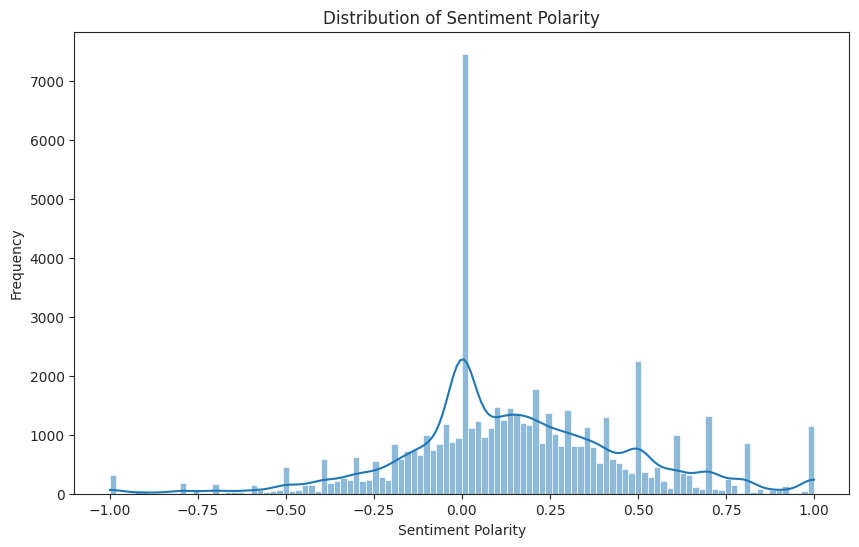

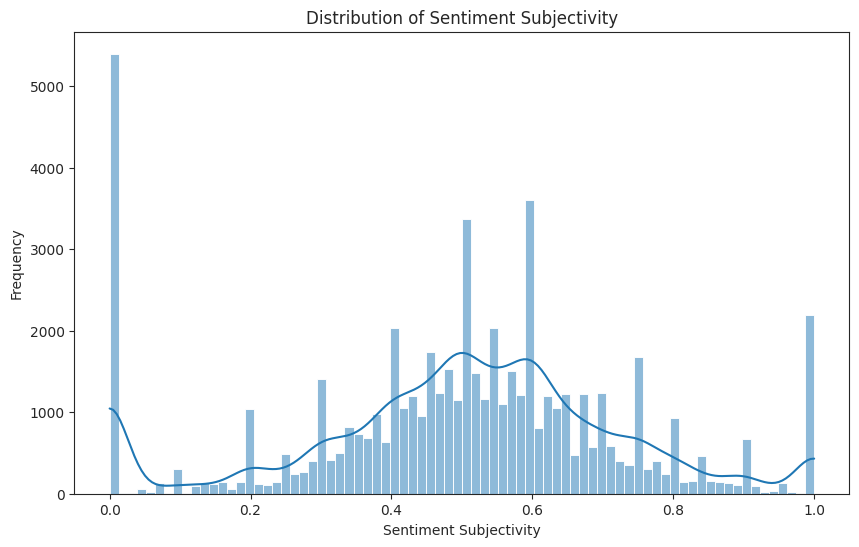

In [168]:
# 1. Deep Dive into User Sentiment

# Distribution of Sentiment Polarity
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['Sentiment_Polarity'].dropna(), kde=True)
plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.show()

# Distribution of Sentiment Subjectivity
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['Sentiment_Subjectivity'].dropna(), kde=True)
plt.title('Distribution of Sentiment Subjectivity')
plt.xlabel('Sentiment Subjectivity')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_5126/2436780912.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sentiment', y='Rating', data=sentiment_analysis, palette='viridis')
/tmp/ipykernel_5126/2436780912.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sentiment', y='Installs', data=sentiment_analysis, palette='magma')


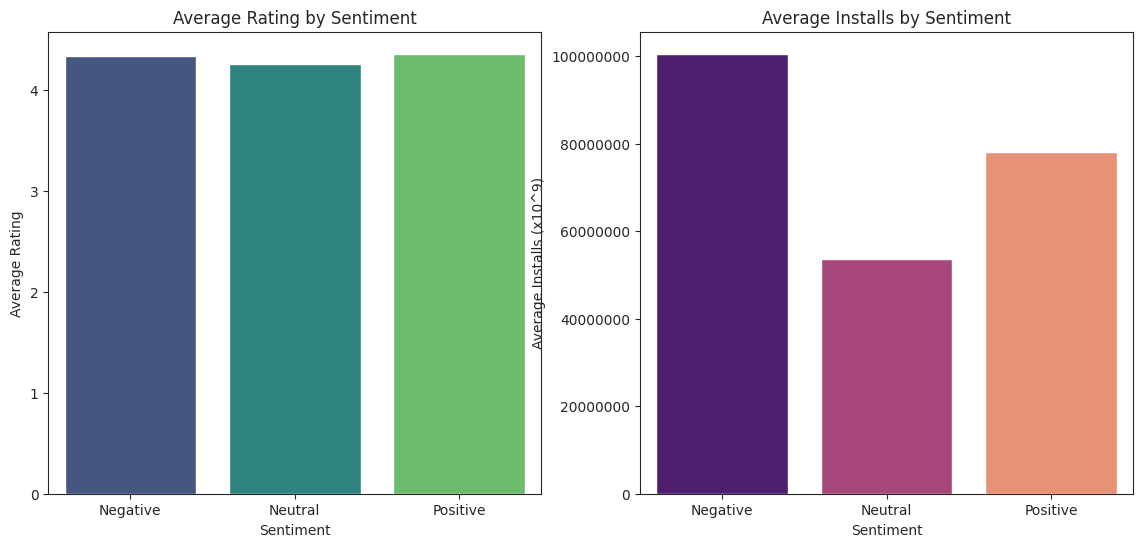

,Sentiment,Rating,Installs
0,Negative,4.337292,1.005222e+08
1,Neutral,4.259808,5.352195e+07
2,Positive,4.357069,7.800810e+07


In [169]:
# Average Rating and Installs by Sentiment
sentiment_analysis = merged_df.groupby('Sentiment')[['Rating', 'Installs']].mean().reset_index()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Sentiment', y='Rating', data=sentiment_analysis, palette='viridis')
plt.title('Average Rating by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Rating')

plt.subplot(1, 2, 2)
sns.barplot(x='Sentiment', y='Installs', data=sentiment_analysis, palette='magma')
plt.title('Average Installs by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Installs (x10^9)') # Adjust label for better readability
plt.ticklabel_format(style='plain', axis='y') # Prevent scientific notation
plt.show()

display(sentiment_analysis)

### 1. Hyperparameter Tuning for Random Forest Regressor

We'll use `GridSearchCV` to systematically work through multiple combinations of parameter tunes and cross-validate each to determine which provides the best performance. This will help us find the optimal settings for our Random Forest model.

In [175]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200],  # Number of trees in the forest
    'max_depth': [10, 20, None], # Maximum number of levels in tree
    'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2]   # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3, # Use 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=2, # Be verbose about the process
    scoring='r2' # Optimize for R-squared
)

print("Starting Grid Search for optimal Random Forest parameters...")
# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

print("Grid Search completed.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"Best Parameters found: {best_params}")
print(f"Best R2 Score (from cross-validation): {best_score}")

# Get the best estimator (the trained model with best parameters)
best_rf_model = grid_search.best_estimator_

# Evaluate the best model on the test set
y_pred_tuned_rf = best_rf_model.predict(X_test)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)

print(f'Tuned Random Forest R2 Score on Test Set: {r2_tuned_rf}')
print(f'Tuned Random Forest Mean Absolute Error on Test Set: {mae_tuned_rf}')

Starting Grid Search for optimal Random Forest parameters...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Grid Search completed.
Best Parameters found: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best R2 Score (from cross-validation): 0.19492801498389498
Tuned Random Forest R2 Score on Test Set: 0.22717961460698544
Tuned Random Forest Mean Absolute Error on Test Set: 0.280367500557235


This process will run for a while, as it trains multiple models with different parameter combinations. Once it's complete, we'll see if the tuned model provides a better R2 score and reduced Mean Absolute Error compared to our initial Random Forest model.

### 2. Exploring a New Model: XGBoost Regressor

We will now train an XGBoost Regressor and evaluate its performance to see if it can provide better accuracy than our Random Forest model.

In [176]:
# First, ensure XGBoost is installed. If not, uncomment and run the following line:
#!pip install xgboost

import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize and train the XGBoost Regressor model
# We'll start with default parameters for a quick comparison, similar to our initial RF model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate the model
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

print(f'XGBoost R2 Score: {r2_xgb}')
print(f'XGBoost Mean Absolute Error: {mae_xgb}')

# Compare with Tuned Random Forest
print(f'\nTuned Random Forest R2 Score: {r2_tuned_rf}')
print(f'Tuned Random Forest Mean Absolute Error: {mae_tuned_rf}')

XGBoost R2 Score: 0.17320982857116662
XGBoost Mean Absolute Error: 0.2964597632369149

Tuned Random Forest R2 Score: 0.22717961460698544
Tuned Random Forest Mean Absolute Error: 0.280367500557235


After executing the cell, we'll compare the R2 score and Mean Absolute Error of the XGBoost model with that of our best-tuned Random Forest model. If XGBoost shows promising results, we could then proceed to hyperparameter tune it further.

These plots provide initial insights into user sentiment. Next, we will discuss **Advanced Feature Engineering for Ratings**, **Explore Different Machine Learning Models**, and **Visualize Market Gaps/Opportunities**.

## 11. Final Insights
- Free apps dominate market
- Reviews strongly influence installs
- Some categories are overcrowded
- Frequent updates improve ratings
- Market gaps exist in less competitive categories